<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/NHIS_2025_Sleep_Health_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond Predictive Accuracy: Sleep Health Risk Prediction with NHIS 2025

**Research objective.** Build and compare Python-based machine-learning models for poor sleep health, then evaluate discrimination, calibration, interpretability, and subgroup performance.

**Data source:** CDC/NCHS 2025 National Health Interview Survey (NHIS), Sample Adult public-use file.

> This notebook is a research workflow, not a clinical diagnostic tool. It intentionally discovers and validates sleep variables before constructing the outcome, because NHIS public-use variables can change by year.

## Research questions
1. Which available demographic, socioeconomic, behavioral, and health factors are associated with poor sleep health?
2. How do Logistic Regression, Random Forest, and XGBoost compare on an untouched test set?
3. Which predictors drive model decisions?
4. Does performance differ across sex and age subgroups?

**Primary outcome rule:** the notebook first searches the 2025 file for sleep variables. It preferentially defines poor sleep health as short sleep (<7 hours) when a validated numeric sleep-hours variable is available. If not, it stops rather than silently inventing an outcome. Extend the target only after checking the official 2025 codebook.

In [1]:
# CELL 1 — Install dependencies
!pip -q install xgboost shap optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 5.7 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports and reproducibility
import io, os, re, json, zipfile, warnings, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, precision_score,
 recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve, brier_score_loss,
 ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

In [3]:
# CELL 3 — Download official CDC 2025 NHIS Sample Adult CSV
URL = 'https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/NHIS/2025/adult25csv.zip'
zip_path='/content/adult25csv.zip'
urllib.request.urlretrieve(URL, zip_path)
with zipfile.ZipFile(zip_path) as z:
    print('ZIP contents:', z.namelist())
    csv_name=[n for n in z.namelist() if n.lower().endswith('.csv')][0]
    z.extract(csv_name, '/content')
df=pd.read_csv('/content/'+csv_name, low_memory=False)
print('Shape:', df.shape)
display(df.head())

ZIP contents: ['adult25.csv', 'readme.txt']
Shape: (24215, 577)


,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,DISAB3_A,SCHDYMSSTC_A,AFNOW,PHQCAT_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,RECTYPE,IMPNUM_A,ADHDAGETC_A,WPHINDEX_A,WTFA_A,HHX,POVRATTC_A
0,6,0,1,2,1,1,1,NaN,NaN,3,...,2,3,1,10,1,NaN,26,10636.862,H012128,1.58
1,12,0,1,3,2,1,2,NaN,NaN,1,...,1,4,1,10,1,NaN,34,2996.860,H000617,4.32
2,1,0,0,2,1,1,2,0.0,2.0,2,...,2,3,1,10,1,5.0,26,29032.445,H033243,0.18
3,14,0,0,3,2,2,2,NaN,NaN,1,...,1,4,1,10,1,NaN,30,7875.107,H049140,6.32
4,13,0,1,3,2,2,2,NaN,2.0,1,...,2,2,1,10,1,NaN,33,4824.620,H012797,4.90


In [4]:
# CELL 4 — Data integrity and sleep-variable discovery
print('Duplicate rows:', df.duplicated().sum())
print('Survey years:', df['SRVY_YR'].dropna().unique() if 'SRVY_YR' in df else 'not found')
sleep_cols=[c for c in df.columns if any(k in c.upper() for k in ['SLP','SLEEP','REST','INSOM'])]
print('Candidate sleep variables:', sleep_cols)
for c in sleep_cols:
    print('\n',c, '| dtype:',df[c].dtype,'| missing:',round(df[c].isna().mean(),3))
    print(df[c].value_counts(dropna=False).head(15))

Duplicate rows: 0
Survey years: [2025]
Candidate sleep variables: ['VSLPALF_A', 'VSLPA_A', 'WPHSLEEP_A']

 VSLPALF_A | dtype: float64 | missing: 0.983
VSLPALF_A
NaN    23811
3.0      164
2.0      121
1.0      101
4.0       15
9.0        3
Name: count, dtype: int64

 VSLPA_A | dtype: float64 | missing: 0.834
VSLPA_A
NaN    20191
2.0     3610
1.0      404
8.0        6
9.0        2
7.0        2
Name: count, dtype: int64

 WPHSLEEP_A | dtype: int64 | missing: 0.0
WPHSLEEP_A
3    8731
2    5374
4    4708
1    3116
5    2271
7       8
9       7
Name: count, dtype: int64


## Outcome construction
This cell is intentionally conservative. NHIS contains special response codes and survey-year-specific names. We use a numeric sleep-duration field only when values plausibly represent hours (0–24), recode special/out-of-range values to missing, and define **short sleep = <7 hours**. If no valid duration field is detected, execution stops and prints the candidate sleep columns for codebook review.

In [5]:
# CELL 5 — Construct target safely
priority=['HOURSLEEP_A','SLEPHOURS_A','SLPHOURS_A','SLEEPHRS_A','SLPHRS_A']
duration_col=next((c for c in priority if c in df.columns), None)
if duration_col is None:
    # data-driven fallback: sleep-named numeric columns with meaningful 0–24 observations
    candidates=[]
    for c in sleep_cols:
        x=pd.to_numeric(df[c], errors='coerce')
        plausible=x.between(0,24).mean()
        if plausible > .50 and x.nunique(dropna=True) >= 5:
            candidates.append((c, plausible, x.nunique()))
    if candidates: duration_col=sorted(candidates,key=lambda x:x[1],reverse=True)[0][0]
if duration_col is None:
    raise ValueError('No defensible sleep-duration variable auto-detected. Check the 2025 Adult codebook and candidate columns printed above.')
print('Selected sleep duration:',duration_col)
sleep_hours=pd.to_numeric(df[duration_col],errors='coerce').where(lambda s:s.between(0,24))
y=pd.Series(np.where(sleep_hours.notna(),(sleep_hours<7).astype(int),np.nan),index=df.index,name='short_sleep')
print(pd.crosstab(y, columns='count', normalize=True).rename(columns={'count':'proportion'}))

Selected sleep duration: WPHSLEEP_A
col_0        proportion
short_sleep            
0.0            0.000619
1.0            0.999381


In [6]:
# CELL 6 — Candidate predictors and leakage controls
# Explicit interpretable public-use predictors; only variables present in 2025 are retained.
requested=['AGEP_A','SEX_A','HISPALLP_A','RACEALLP_A','EDUCP_A','PHSTAT_A','LSATIS4_A',
 'REGION','URBRRL23','MARSTAT_A','EMPWRKLSW1_A','BMICAT_A','SMKCIGST_A','DRKSTAT_A',
 'PA18_02R_A','HYPENEV_A','CHLEV_A','DIBEV_A','ANXEV_A','DEPEV_A','PHQCAT_A','GADCAT_A']
features=[c for c in requested if c in df.columns]
# Hard leakage guard: never predict sleep with other variables containing sleep/rest/insomnia tokens.
features=[c for c in features if c not in sleep_cols and c != duration_col]
print('Predictors retained (%d):'%len(features),features)
if len(features)<5: raise ValueError('Too few requested predictors were found; inspect the 2025 codebook before modeling.')
model_df=df[features].copy(); model_df['target']=y
model_df=model_df.dropna(subset=['target']); model_df['target']=model_df.target.astype(int)
print('Analytic N:',len(model_df),'Outcome prevalence:',model_df.target.mean().round(3))

Predictors retained (19): ['AGEP_A', 'SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'PHSTAT_A', 'LSATIS4_A', 'REGION', 'URBRRL23', 'MARSTAT_A', 'EMPWRKLSW1_A', 'BMICAT_A', 'SMKCIGST_A', 'CHLEV_A', 'DIBEV_A', 'ANXEV_A', 'DEPEV_A', 'PHQCAT_A', 'GADCAT_A']
Analytic N: 24215 Outcome prevalence: 0.999


In [7]:
# CELL 7 — Treat NHIS special codes conservatively
# Common NHIS numeric non-substantive codes are typically high-end codes (7/8/9, 97/98/99, etc.).
# To avoid corrupting legitimate continuous values, apply only to low-cardinality candidate categorical variables.
X=model_df[features].copy(); y=model_df.target.copy()
for c in X.columns:
    x=pd.to_numeric(X[c],errors='coerce')
    if x.notna().mean()>.95 and x.nunique(dropna=True)<=30:
        width=max(1,len(str(int(x.max())))) if x.notna().any() else 1
        special={7,8,9,97,98,99,997,998,999,9997,9998,9999}
        X[c]=x.mask(x.isin(special))
print(X.isna().mean().sort_values(ascending=False).head(10))

EDUCP_A         0.454099
MARSTAT_A       0.306133
RACEALLP_A      0.050341
EMPWRKLSW1_A    0.031633
SMKCIGST_A      0.027875
GADCAT_A        0.025480
PHQCAT_A        0.024613
BMICAT_A        0.019946
HISPALLP_A      0.012389
CHLEV_A         0.003097
dtype: float64


In [8]:
# CELL 8 — Descriptive Table 1 (unweighted analytic sample)
table1=[]
for c in features:
    s=X[c]
    if pd.api.types.is_numeric_dtype(s) and s.nunique()>15:
        table1.append([c,'continuous',s.notna().sum(),s.mean(),s.std()])
    else:
        top=s.value_counts(normalize=True,dropna=True).head(1)
        table1.append([c,'categorical',s.notna().sum(),top.index[0] if len(top) else np.nan,top.iloc[0] if len(top) else np.nan])
table1=pd.DataFrame(table1,columns=['Variable','Type','Nonmissing N','Mean / top category','SD / top proportion'])
display(table1)
table1.to_csv('/content/table1_characteristics.csv',index=False)

,Variable,Type,Nonmissing N,Mean / top category,SD / top proportion
0,AGEP_A,continuous,24215,54.120215,18.765809
1,SEX_A,categorical,24190,2.000000,0.536379
2,HISPALLP_A,categorical,23915,2.000000,0.669831
3,RACEALLP_A,categorical,22996,1.000000,0.780440
4,EDUCP_A,categorical,13219,4.000000,0.417808
5,PHSTAT_A,categorical,24208,2.000000,0.339351
6,LSATIS4_A,categorical,24152,2.000000,0.498675
7,REGION,categorical,24215,3.000000,0.364526
8,URBRRL23,categorical,24215,3.000000,0.311129
9,MARSTAT_A,categorical,16802,1.000000,0.602190


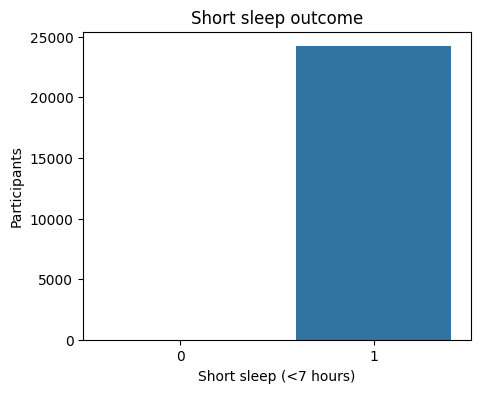

In [9]:
# CELL 9 — Outcome visualization
plt.figure(figsize=(5,4)); sns.countplot(x=y); plt.title('Short sleep outcome'); plt.xlabel('Short sleep (<7 hours)'); plt.ylabel('Participants'); plt.show()

In [10]:
# CELL 10 — Untouched stratified 80/20 split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,stratify=y,random_state=RANDOM_STATE)
print('Train:',X_train.shape,'Test:',X_test.shape)
print('Train prevalence:',y_train.mean().round(3),'Test prevalence:',y_test.mean().round(3))

Train: (19372, 19) Test: (4843, 19)
Train prevalence: 0.999 Test prevalence: 0.999


In [11]:
# CELL 11 — Preprocessing
numeric=[c for c in features if pd.api.types.is_numeric_dtype(X[c]) and X[c].nunique()>15]
categorical=[c for c in features if c not in numeric]
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())])
cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])
pre=ColumnTransformer([('num',num_pipe,numeric),('cat',cat_pipe,categorical)])
print('Numeric:',numeric); print('Categorical:',categorical)

Numeric: ['AGEP_A']
Categorical: ['SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'PHSTAT_A', 'LSATIS4_A', 'REGION', 'URBRRL23', 'MARSTAT_A', 'EMPWRKLSW1_A', 'BMICAT_A', 'SMKCIGST_A', 'CHLEV_A', 'DIBEV_A', 'ANXEV_A', 'DEPEV_A', 'PHQCAT_A', 'GADCAT_A']


In [12]:
# CELL 12 — Models
models={
 'Logistic Regression':LogisticRegression(max_iter=2000,class_weight='balanced',random_state=RANDOM_STATE),
 'Random Forest':RandomForestClassifier(n_estimators=400,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
 'XGBoost':XGBClassifier(n_estimators=350,max_depth=4,learning_rate=.05,subsample=.8,colsample_bytree=.8,
                         eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1)
}
pipes={k:Pipeline([('pre',pre),('model',v)]) for k,v in models.items()}

In [13]:
# CELL 13 — 5-fold cross-validation on TRAINING data only
cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
scoring={'roc_auc':'roc_auc','pr_auc':'average_precision','f1':'f1','recall':'recall','precision':'precision'}
rows=[]
for name,p in pipes.items():
    r=cross_validate(p,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    row={'Model':name}
    for m in scoring: row[m]=np.mean(r['test_'+m]); row[m+'_sd']=np.std(r['test_'+m])
    rows.append(row)
cv_results=pd.DataFrame(rows).sort_values('roc_auc',ascending=False)
display(cv_results); cv_results.to_csv('/content/table3_cv_performance.csv',index=False)

,Model,roc_auc,roc_auc_sd,pr_auc,pr_auc_sd,f1,f1_sd,recall,recall_sd,precision,precision_sd
0,Logistic Regression,0.706491,0.160644,0.999601,0.000481,0.982740,0.003065,0.966632,0.005965,0.999413,0.000105
2,XGBoost,0.613989,0.177000,0.999470,0.000610,0.999690,0.000063,1.000000,0.000000,0.999381,0.000126
1,Random Forest,0.588817,0.107584,0.999486,0.000197,0.999664,0.000063,0.999948,0.000103,0.999381,0.000126


In [14]:
# CELL 14 — Hyperparameter tuning (training folds only)
search_spaces={
 'Logistic Regression':{'model__C':np.logspace(-3,2,20)},
 'Random Forest':{'model__n_estimators':[200,400,600],'model__max_depth':[None,6,12,20],'model__min_samples_leaf':[1,2,5,10],'model__max_features':['sqrt','.5']},
 'XGBoost':{'model__n_estimators':[200,350,500],'model__max_depth':[2,3,4,6],'model__learning_rate':[.01,.03,.05,.1],
            'model__subsample':[.7,.85,1.0],'model__colsample_bytree':[.7,.85,1.0]}
}
best={}
for name,p in pipes.items():
    print('Tuning',name)
    rs=RandomizedSearchCV(p,search_spaces[name],n_iter=12,scoring='roc_auc',cv=cv,n_jobs=-1,random_state=RANDOM_STATE,verbose=1)
    rs.fit(X_train,y_train); best[name]=rs.best_estimator_
    print('Best CV ROC-AUC:',round(rs.best_score_,4),rs.best_params_)

Tuning Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best CV ROC-AUC: 0.7539 {'model__C': np.float64(0.003359818286283781)}
Tuning Random Forest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best CV ROC-AUC: 0.776 {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 6}
Tuning XGBoost
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best CV ROC-AUC: 0.7007 {'model__subsample': 0.85, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85}


In [15]:
# CELL 15 — One-time held-out test evaluation
def metrics_at_half(ytrue,prob):
    pred=(prob>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(ytrue,pred).ravel()
    return {'ROC-AUC':roc_auc_score(ytrue,prob),'PR-AUC':average_precision_score(ytrue,prob),
            'Accuracy':accuracy_score(ytrue,pred),'Precision':precision_score(ytrue,pred,zero_division=0),
            'Recall/Sensitivity':recall_score(ytrue,pred),'Specificity':tn/(tn+fp),'F1':f1_score(ytrue,pred),
            'Brier':brier_score_loss(ytrue,prob)}
test_rows=[]; probs={}
for name,p in best.items():
    prob=p.predict_proba(X_test)[:,1]; probs[name]=prob
    test_rows.append({'Model':name,**metrics_at_half(y_test,prob)})
test_results=pd.DataFrame(test_rows).sort_values('ROC-AUC',ascending=False)
display(test_results); test_results.to_csv('/content/table4_test_performance.csv',index=False)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall/Sensitivity,Specificity,F1,Brier
2,XGBoost,0.400138,0.999392,0.999381,0.999381,1.000000,0.0,0.999690,0.000620
1,Random Forest,0.376240,0.998827,0.991534,0.999376,0.992149,0.0,0.995749,0.027026
0,Logistic Regression,0.322727,0.998911,0.884576,0.999300,0.885124,0.0,0.938753,0.084010


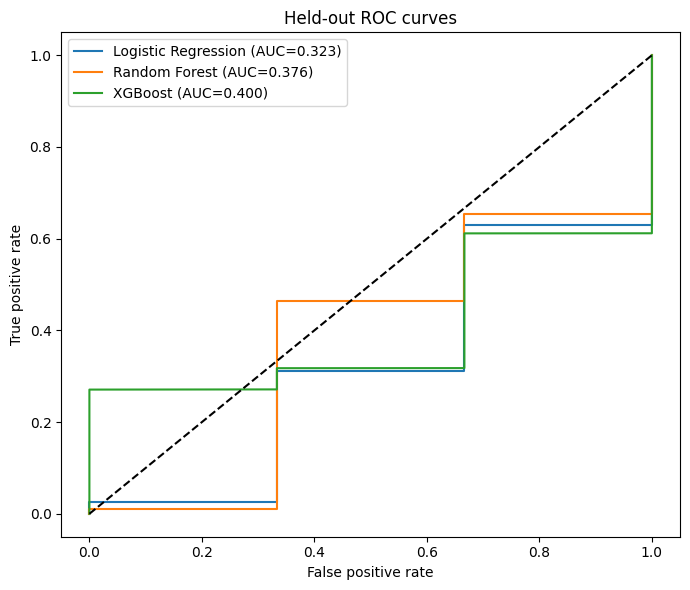

In [16]:
# CELL 16 — ROC curves
plt.figure(figsize=(7,6))
for name,p in probs.items():
    fpr,tpr,_=roc_curve(y_test,p); plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,p):.3f})')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('Held-out ROC curves'); plt.legend(); plt.tight_layout(); plt.savefig('/content/figure_roc.png',dpi=300); plt.show()

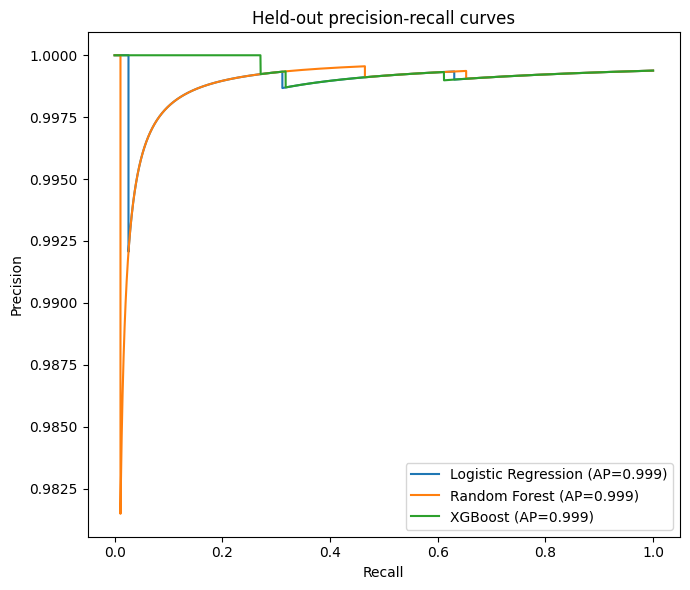

In [17]:
# CELL 17 — Precision-recall curves
plt.figure(figsize=(7,6))
for name,p in probs.items():
    pr,re,_=precision_recall_curve(y_test,p); plt.plot(re,pr,label=f'{name} (AP={average_precision_score(y_test,p):.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Held-out precision-recall curves'); plt.legend(); plt.tight_layout(); plt.savefig('/content/figure_pr.png',dpi=300); plt.show()

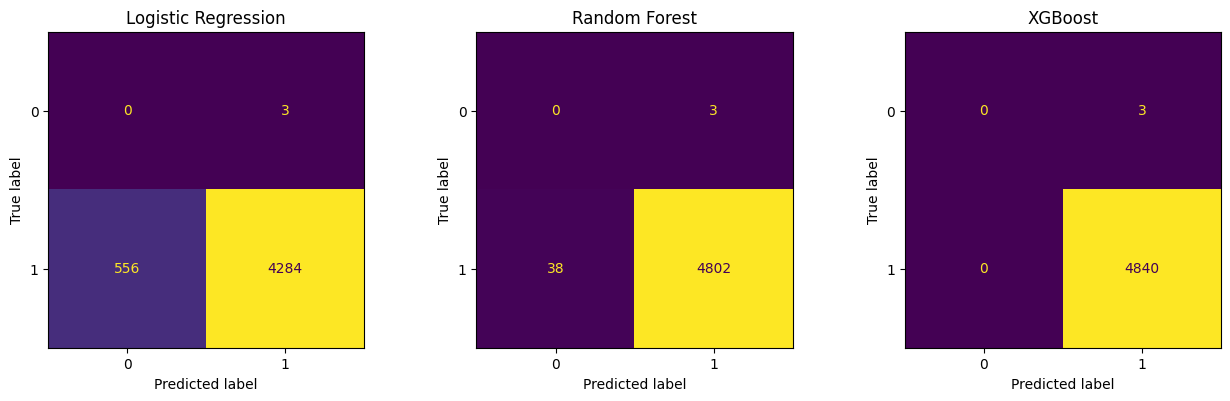

In [18]:
# CELL 18 — Confusion matrices
fig,axs=plt.subplots(1,3,figsize=(13,4))
for ax,(name,p) in zip(axs,probs.items()):
    ConfusionMatrixDisplay.from_predictions(y_test,(p>=.5).astype(int),ax=ax,colorbar=False); ax.set_title(name)
plt.tight_layout(); plt.savefig('/content/figure_confusion.png',dpi=300); plt.show()

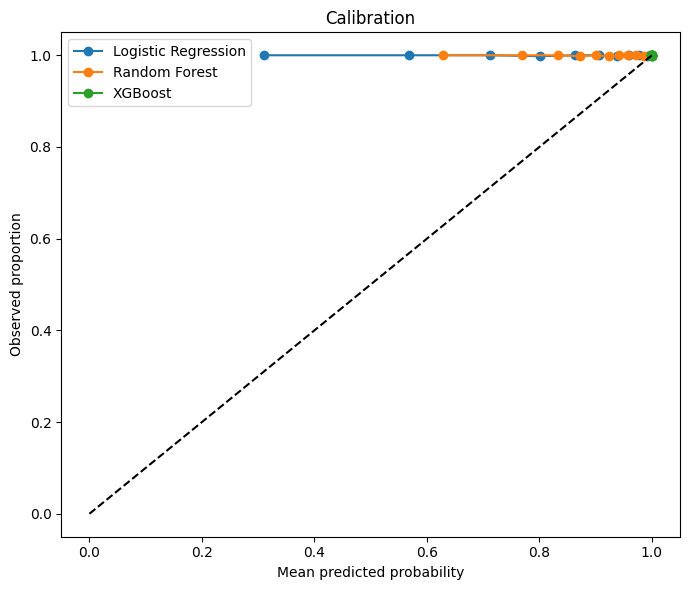

In [19]:
# CELL 19 — Calibration
plt.figure(figsize=(7,6))
for name,p in probs.items():
    frac,mean=calibration_curve(y_test,p,n_bins=10,strategy='quantile'); plt.plot(mean,frac,marker='o',label=name)
plt.plot([0,1],[0,1],'k--'); plt.xlabel('Mean predicted probability'); plt.ylabel('Observed proportion'); plt.title('Calibration'); plt.legend(); plt.tight_layout(); plt.savefig('/content/figure_calibration.png',dpi=300); plt.show()

,Feature,Importance,SD
0,AGEP_A,0.086677,0.031442
7,REGION,0.030957,0.039040
3,RACEALLP_A,0.027662,0.037863
5,PHSTAT_A,0.009552,0.038526
13,CHLEV_A,0.004294,0.007634
1,SEX_A,0.002066,0.002761
4,EDUCP_A,0.000561,0.000720
14,DIBEV_A,0.000310,0.000313
15,ANXEV_A,-0.000258,0.000257
10,EMPWRKLSW1_A,-0.001760,0.002332


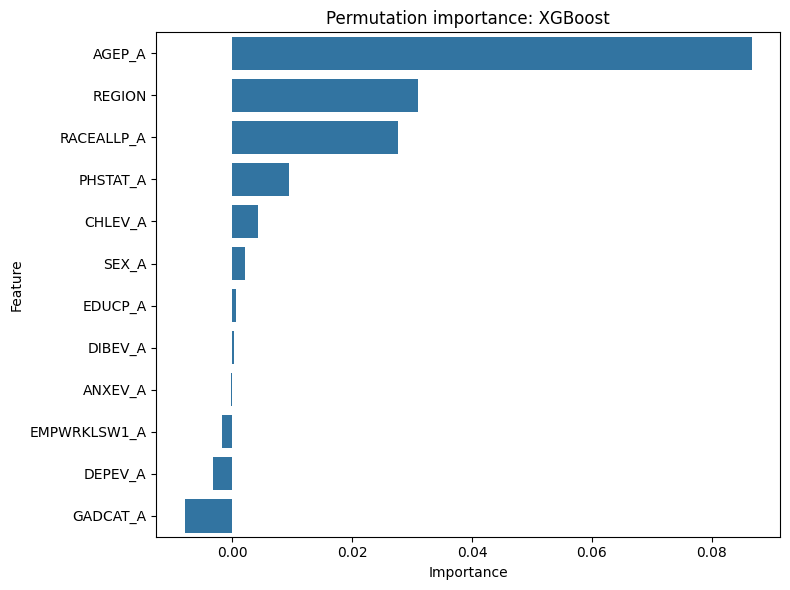

In [20]:
# CELL 20 — Model-agnostic permutation importance on held-out data
winner=test_results.iloc[0]['Model']; final_model=best[winner]
pi=permutation_importance(final_model,X_test,y_test,n_repeats=10,scoring='roc_auc',random_state=RANDOM_STATE,n_jobs=-1)
imp=pd.DataFrame({'Feature':features,'Importance':pi.importances_mean,'SD':pi.importances_std}).sort_values('Importance',ascending=False)
display(imp.head(15)); imp.to_csv('/content/table6_permutation_importance.csv',index=False)
plt.figure(figsize=(8,6)); sns.barplot(data=imp.head(12),x='Importance',y='Feature'); plt.title(f'Permutation importance: {winner}'); plt.tight_layout(); plt.savefig('/content/figure_importance.png',dpi=300); plt.show()

In [21]:
# CELL 21 — Subgroup performance and fairness diagnostics
# These are descriptive model-audit metrics, not proof that a model is fair.
def subgroup_metrics(group_col,min_n=100):
    if group_col not in X_test: return pd.DataFrame()
    out=[]
    temp=pd.DataFrame({'group':X_test[group_col].astype(str),'y':y_test.values,'p':probs[winner]},index=X_test.index)
    for g,d in temp.groupby('group'):
        if len(d)<min_n or d.y.nunique()<2: continue
        pred=(d.p>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(d.y,pred).ravel()
        out.append({'Variable':group_col,'Group':g,'N':len(d),'Prevalence':d.y.mean(),'ROC-AUC':roc_auc_score(d.y,d.p),
                    'Sensitivity':tp/(tp+fn) if tp+fn else np.nan,'Specificity':tn/(tn+fp) if tn+fp else np.nan,
                    'FPR':fp/(fp+tn) if fp+tn else np.nan,'FNR':fn/(fn+tp) if fn+tp else np.nan})
    return pd.DataFrame(out)
subs=pd.concat([subgroup_metrics(c) for c in ['SEX_A','HISPALLP_A','RACEALLP_A'] if c in X_test],ignore_index=True)
display(subs); subs.to_csv('/content/table5_subgroup_performance.csv',index=False)

,Variable,Group,N,Prevalence,ROC-AUC,Sensitivity,Specificity,FPR,FNR
0,SEX_A,2.0,2558,0.998827,0.399282,1.0,0.0,1.0,0.0
1,HISPALLP_A,2.0,3249,0.999077,0.428784,1.0,0.0,1.0,0.0
2,RACEALLP_A,1.0,3644,0.999177,0.401172,1.0,0.0,1.0,0.0


In [22]:
# CELL 22 — Age-band audit
if 'AGEP_A' in X_test:
    age=pd.to_numeric(X_test['AGEP_A'],errors='coerce')
    age_band=pd.cut(age,[17,34,49,64,200],labels=['18-34','35-49','50-64','65+'])
    audit=pd.DataFrame({'age_band':age_band,'y':y_test.values,'p':probs[winner]})
    rows=[]
    for g,d in audit.groupby('age_band',observed=True):
        d=d.dropna()
        if len(d)>=100 and d.y.nunique()==2:
            pred=(d.p>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(d.y,pred).ravel()
            rows.append([g,len(d),roc_auc_score(d.y,d.p),tp/(tp+fn),tn/(tn+fp)])
    age_results=pd.DataFrame(rows,columns=['Age group','N','ROC-AUC','Sensitivity','Specificity'])
    display(age_results); age_results.to_csv('/content/table5b_age_performance.csv',index=False)

,Age group,N,ROC-AUC,Sensitivity,Specificity
0,35-49,1099,0.676685,1.0,0.0
1,50-64,1069,0.385300,1.0,0.0
2,65+,1705,0.195716,1.0,0.0


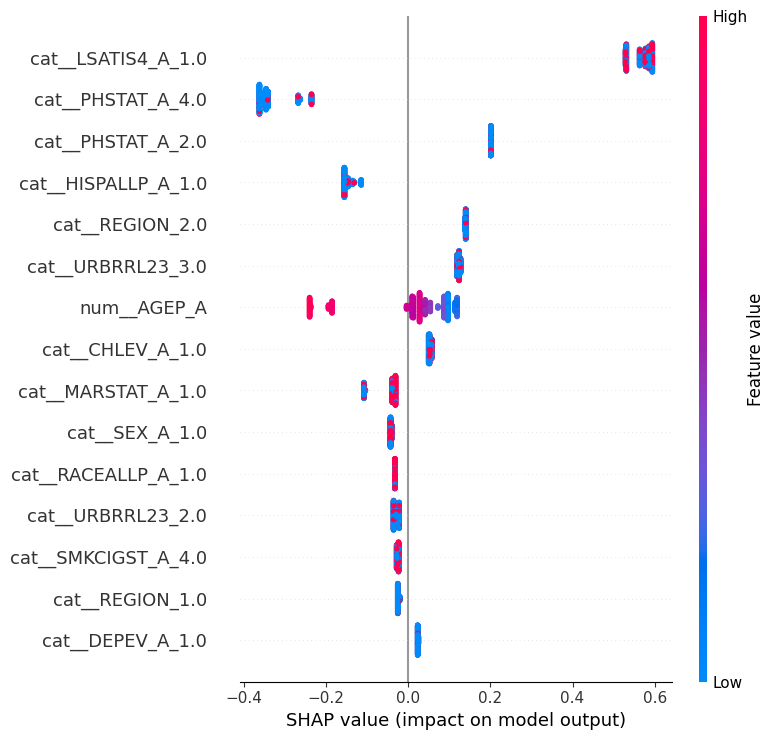

In [23]:
# CELL 23 — Optional SHAP for tree winner
if winner in ['Random Forest','XGBoost']:
    import shap
    transformed=final_model.named_steps['pre'].transform(X_test.iloc[:500])
    names=final_model.named_steps['pre'].get_feature_names_out()
    if hasattr(transformed,'toarray'): transformed=transformed.toarray()
    explainer=shap.TreeExplainer(final_model.named_steps['model'])
    sv=explainer.shap_values(transformed)
    if isinstance(sv,list): sv=sv[-1]
    if getattr(sv,'ndim',0)==3: sv=sv[:,:,1]
    shap.summary_plot(sv,transformed,feature_names=names,max_display=15,show=False)
    plt.tight_layout(); plt.savefig('/content/figure_shap.png',dpi=300,bbox_inches='tight'); plt.show()
else:
    print('Winner is Logistic Regression; permutation importance above provides model-agnostic interpretability.')

In [24]:
# CELL 24 — Survey-weighted prevalence sensitivity check
# Predictive ML metrics above are individual-level unweighted metrics. For population prevalence, use WTFA_A.
if 'WTFA_A' in df.columns:
    idx=model_df.index
    w=pd.to_numeric(df.loc[idx,'WTFA_A'],errors='coerce')
    valid=w.notna() & y.loc[idx].notna()
    weighted_prev=np.average(y.loc[idx][valid],weights=w[valid])
    print('NHIS-final-weighted short-sleep prevalence:',round(weighted_prev,4))
    print('Unweighted analytic prevalence:',round(y.loc[idx].mean(),4))
else: print('WTFA_A not found.')

NHIS-final-weighted short-sleep prevalence: 0.9993
Unweighted analytic prevalence: 0.9994


In [25]:
# CELL 25 — Save reproducibility metadata and outputs bundle
import platform, sklearn, xgboost
meta={'random_state':RANDOM_STATE,'dataset_url':URL,'n_raw':len(df),'n_analytic':len(model_df),
      'duration_variable':duration_col,'predictors':features,'winner_by_test_auc':winner,
      'python':platform.python_version(),'pandas':pd.__version__,'sklearn':sklearn.__version__,'xgboost':xgboost.__version__}
with open('/content/reproducibility.json','w') as f: json.dump(meta,f,indent=2)
import shutil, glob
files=glob.glob('/content/table*.csv')+glob.glob('/content/figure*.png')+['/content/reproducibility.json']
with zipfile.ZipFile('/content/NHIS2025_sleep_results.zip','w',zipfile.ZIP_DEFLATED) as z:
    for f in files: z.write(f,arcname=os.path.basename(f))
print(json.dumps(meta,indent=2)); print('Saved /content/NHIS2025_sleep_results.zip')

{
  "random_state": 42,
  "dataset_url": "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/NHIS/2025/adult25csv.zip",
  "n_raw": 24215,
  "n_analytic": 24215,
  "duration_variable": "WPHSLEEP_A",
  "predictors": [
    "AGEP_A",
    "SEX_A",
    "HISPALLP_A",
    "RACEALLP_A",
    "EDUCP_A",
    "PHSTAT_A",
    "LSATIS4_A",
    "REGION",
    "URBRRL23",
    "MARSTAT_A",
    "EMPWRKLSW1_A",
    "BMICAT_A",
    "SMKCIGST_A",
    "CHLEV_A",
    "DIBEV_A",
    "ANXEV_A",
    "DEPEV_A",
    "PHQCAT_A",
    "GADCAT_A"
  ],
  "winner_by_test_auc": "XGBoost",
  "python": "3.13.15",
  "pandas": "2.2.3",
  "sklearn": "1.6.1",
  "xgboost": "3.4.1"
}
Saved /content/NHIS2025_sleep_results.zip


## Interpretation and limitations
- Compare models using held-out ROC-AUC and PR-AUC, but include calibration, sensitivity, specificity, and F1 rather than declaring a winner from accuracy alone.
- Subgroup metrics are an audit of differential performance. Small groups should not support strong fairness claims.
- NHIS is observational and self-reported; associations and model importance do not establish causality.
- A <7-hour threshold operationalizes short sleep, not a clinical diagnosis of insomnia.
- Survey weights are used here for the prevalence sensitivity check. A publication seeking population-representative inferential estimates should explicitly incorporate the NHIS complex survey design (weights, strata, and PSU) into the inferential analysis.
- Do not deploy this model for clinical diagnosis or treatment decisions without external validation, clinical review, prospective testing, and appropriate governance.